In [23]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.stats as stats
from tqdm import tqdm



In [ ]:
# --- GENERAL VISUAL CONFIGURATION ---
mpl.rcParams['hatch.linewidth'] = 0.4  
mpl.rcParams['hatch.color'] = 'black'

TAMANO_FUENTE_EJES = 12
TAMANO_FUENTE_CBAR = 12
TAMANO_FUENTE_TITULO = 14

# --- PATH CONFIGURATION ---
base_path = r"../data/data/"
file_sm = base_path + "Soil_moisture_monthly_COMBINED_1980_2022_box_NEW.nc"
file_era5 = base_path + "volumetric_ERA5_land_1980_2022_box_interpolated_NEW.nc"
file_mask = base_path + "mascara_final_egipto_v2.nc"


print(f"Soil moisture file: {file_sm}")
print(f"ERA5 file: {file_era5}")
print(f"Mask file: {file_mask}")

Soil moisture file: ../data/input_data/Soil_moisture_monthly_COMBINED_1980_2022_box_NEW.nc
ERA5 file: ../data/input_data/volumetric_ERA5_land_1980_2022_box_interpolated_NEW.nc
Mask file: ../data/input_data/mascara_final_egipto_v2.nc


In [25]:
# --- DATA LOADING ---
print("\n[INFO] Loading datasets...")
ds_sm = xr.open_dataset(file_sm)
ds_era = xr.open_dataset(file_era5)
ds_mask = xr.open_dataset(file_mask)

print("[INFO] Datasets loaded successfully")
print(f"SM dimensions: {ds_sm.dims}")
print(f"ERA5 dimensions: {ds_era.dims}")
print(f"Mask dimensions: {ds_mask.dims}")

# --- ALIGNMENT ---
print("\n[INFO] Aligning datasets...")
ds_sm, ds_era = xr.align(ds_sm, ds_era, join="override")
print("[INFO] Alignment completed")

layers = {
    "Layer 1": ds_era["swvl1"],
    "Layer 2": ds_era["swvl1"] + ds_era["swvl2"],
    "Layer 3": ds_era["swvl1"] + ds_era["swvl2"] + ds_era["swvl3"]
}



[INFO] Loading datasets...
[INFO] Datasets loaded successfully
SM dimensions: Frozen({'time': 516, 'bnds': 2, 'lon': 252, 'lat': 64})
ERA5 dimensions: Frozen({'valid_time': 516, 'lon': 252, 'lat': 64})
Mask dimensions: Frozen({'lat': 171, 'lon': 611})

[INFO] Aligning datasets...
[INFO] Alignment completed


g:\ESAproject\FINAL_REPORT\CODE_FINAL\MARINA_EG_ES\pyeoaf\Lib\site-packages\xarray\coding\times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [26]:

def get_corr_map_memory_safe(da_sm, da_era, layer_name):
    """Compute correlation in a memory-safe way using NumPy and show progress."""
    
    print(f"\n[INFO] Starting correlation for {layer_name}")
    
    sm_vals = da_sm.values
    era_vals = da_era.values
    
    n_lat, n_lon = sm_vals.shape[1], sm_vals.shape[2]
    
    print(f"[INFO] Grid size: {n_lat} lat x {n_lon} lon")
    print(f"[INFO] Time steps: {sm_vals.shape[0]}")
    
    corr = np.full((n_lat, n_lon), np.nan)
    p_values = np.full((n_lat, n_lon), np.nan)
    
    for i in tqdm(range(n_lat), desc=f"{layer_name}", unit="lat"):
        x = sm_vals[:, i, :]
        y = era_vals[:, i, :]
        
        valid = ~np.isnan(x) & ~np.isnan(y)
        n_valid = np.sum(valid, axis=0)
        
        with np.errstate(invalid='ignore'):
            x_mean = np.nanmean(x, axis=0)
            y_mean = np.nanmean(y, axis=0)
            x_anom = x - x_mean
            y_anom = y - y_mean
            
            cov = np.nansum(x_anom * y_anom, axis=0)
            x_var = np.nansum(x_anom**2, axis=0)
            y_var = np.nansum(y_anom**2, axis=0)
            
            r = cov / np.sqrt(x_var * y_var)
            
            t_stat = r * np.sqrt((n_valid - 2) / (1 - r**2))
            pval = 2 * (1 - stats.t.cdf(np.abs(t_stat), n_valid - 2))
            
            corr[i, :] = r
            p_values[i, :] = pval

    print(f"[INFO] Finished {layer_name}")
    print(f"[STATS] Mean r: {np.nanmean(corr):.3f}")
    print(f"[STATS] Min r: {np.nanmin(corr):.3f}")
    print(f"[STATS] Max r: {np.nanmax(corr):.3f}")
    print(f"[STATS] Significant points (p<0.05): {np.sum(p_values < 0.05)}")

    return corr, p_values


[INFO] Starting correlation for Layer 1
[INFO] Grid size: 64 lat x 252 lon
[INFO] Time steps: 516


Layer 1:   0%|          | 0/64 [00:00<?, ?lat/s]C:\Users\ephyslab\AppData\Local\Temp\ipykernel_32844\652918948.py:25: RuntimeWarning: Mean of empty slice
  x_mean = np.nanmean(x, axis=0)
C:\Users\ephyslab\AppData\Local\Temp\ipykernel_32844\652918948.py:26: RuntimeWarning: Mean of empty slice
  y_mean = np.nanmean(y, axis=0)
Layer 1: 100%|██████████| 64/64 [00:00<00:00, 914.27lat/s]


[INFO] Finished Layer 1
[STATS] Mean r: 0.601
[STATS] Min r: -0.059
[STATS] Max r: 0.948
[STATS] Significant points (p<0.05): 9362

[INFO] Starting correlation for Layer 2
[INFO] Grid size: 64 lat x 252 lon
[INFO] Time steps: 516


Layer 2:   0%|          | 0/64 [00:00<?, ?lat/s]C:\Users\ephyslab\AppData\Local\Temp\ipykernel_32844\652918948.py:25: RuntimeWarning: Mean of empty slice
  x_mean = np.nanmean(x, axis=0)
C:\Users\ephyslab\AppData\Local\Temp\ipykernel_32844\652918948.py:26: RuntimeWarning: Mean of empty slice
  y_mean = np.nanmean(y, axis=0)
Layer 2: 100%|██████████| 64/64 [00:00<00:00, 955.19lat/s]


[INFO] Finished Layer 2
[STATS] Mean r: 0.469
[STATS] Min r: -0.053
[STATS] Max r: 0.941
[STATS] Significant points (p<0.05): 9329

[INFO] Starting correlation for Layer 3
[INFO] Grid size: 64 lat x 252 lon
[INFO] Time steps: 516


Layer 3:   0%|          | 0/64 [00:00<?, ?lat/s]C:\Users\ephyslab\AppData\Local\Temp\ipykernel_32844\652918948.py:25: RuntimeWarning: Mean of empty slice
  x_mean = np.nanmean(x, axis=0)
C:\Users\ephyslab\AppData\Local\Temp\ipykernel_32844\652918948.py:26: RuntimeWarning: Mean of empty slice
  y_mean = np.nanmean(y, axis=0)
Layer 3: 100%|██████████| 64/64 [00:00<00:00, 941.15lat/s]

[INFO] Finished Layer 3
[STATS] Mean r: 0.444
[STATS] Min r: -0.052
[STATS] Max r: 0.931
[STATS] Significant points (p<0.05): 9259


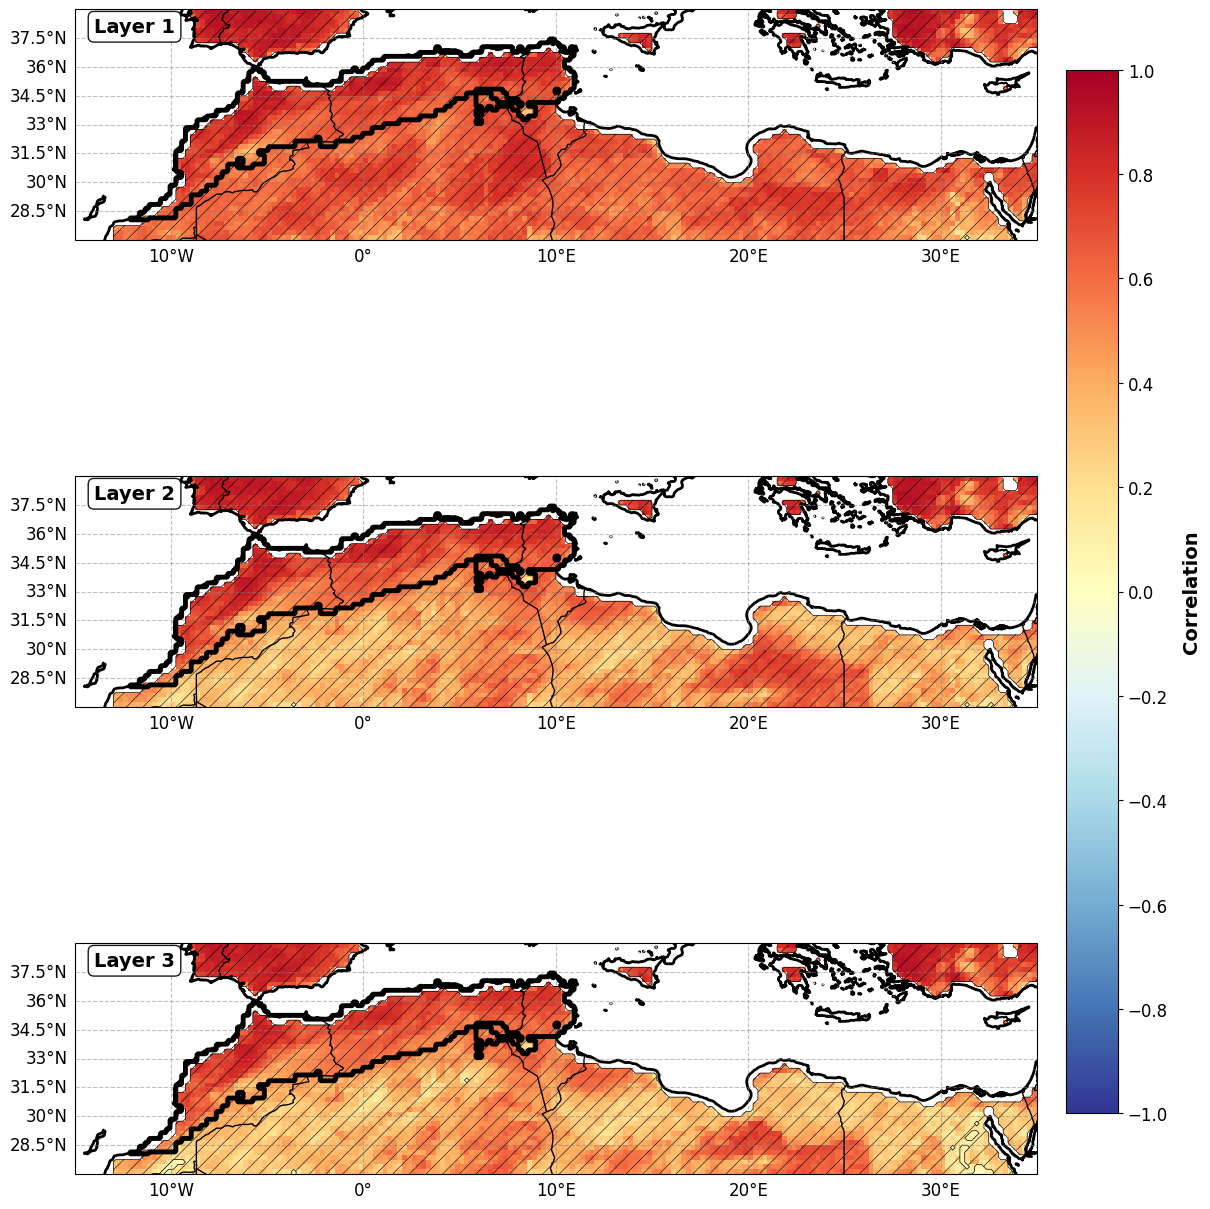

In [27]:
# Preparar los datos de la máscara (rellenar NaNs con 0 para que el contorno se cierre bien)
mask_data = ds_mask['mask'].fillna(0).values
mask_lon = ds_mask['lon'].values
mask_lat = ds_mask['lat'].values

# --- GENERACIÓN DE LA FIGURA ---
fig, axes = plt.subplots(3, 1, figsize=(12, 14), 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

lon, lat = ds_sm.lon.values, ds_sm.lat.values

for i, (label, era_data) in enumerate(layers.items()):
    ax = axes[i]
    
    corr, pval = get_corr_map_memory_safe(ds_sm["sm"], era_data, label)
    
    # Rango de colores de -1 a 1
    im = ax.pcolormesh(lon, lat, corr, cmap="RdYlBu_r", vmin=-1.0, vmax=1.0)
    
    # Áreas significativas: p < 0.05
    sig_mask = np.where(pval < 0.05, 1, 0)
    ax.contourf(lon, lat, sig_mask, levels=[0.5, 1.5], 
                hatches=['//'], colors='none', alpha=0)
    ax.contour(lon, lat, sig_mask, levels=[0.5], colors='black', linewidths=0.5)

    # --- NUEVO: Dibujar el contorno de la máscara de estudio ---
    ax.contour(mask_lon, mask_lat, mask_data, levels=[0.5], 
               colors='black', linewidths=3.5, transform=ccrs.PlateCarree(), zorder=4)

    # Detalles del mapa: continentes y fronteras
    ax.add_feature(cfeature.COASTLINE, linewidth=2.0, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1.0, edgecolor='black')
    ax.set_extent([-15, 35, 27, 39], crs=ccrs.PlateCarree()) 
    
    # Etiquetas de capa
    ax.text(0.02, 0.90, label, transform=ax.transAxes, fontsize=TAMANO_FUENTE_TITULO, fontweight='bold', 
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.3'), zorder=5)
    
    # Grilla y tamaño de números en los ejes
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': TAMANO_FUENTE_EJES, 'color': 'black'}
    gl.ylabel_style = {'size': TAMANO_FUENTE_EJES, 'color': 'black'}

# Barra de colores ajustada
cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.75, pad=0.03)
cbar.set_label('Correlation', fontsize=TAMANO_FUENTE_TITULO, fontweight='bold', labelpad=10)
cbar.set_ticks(np.arange(-1.0, 1.1, 0.2))
cbar.ax.tick_params(labelsize=TAMANO_FUENTE_CBAR)

# --- GUARDAR FIGURAS ---
archivo_salida = base_path + "comparativa_correlaciones_final_mask"

plt.savefig(archivo_salida + ".png", format="png", dpi=300, bbox_inches="tight")
plt.savefig(archivo_salida + ".pdf", format="pdf", bbox_inches="tight")

plt.show()